In [7]:
#1.读取data中2023_6文件夹中的openrank数据集，分析美国排名前一百的项目的的value的最大值、最小值、均值以及中位数。
import pandas as pd

def analyze_openrank(file_path, top_n=100):
    data = pd.read_csv(file_path)
    top_data = data.nlargest(top_n, 'rank')
    value_stats = {
        "max": top_data['value'].max(),
        "min": top_data['value'].min(),
        "mean": top_data['value'].mean(),
        "median": top_data['value'].median()
    }
    print("OpenRank 数据分析结果（前 100 项目）：")
    print(f"最大值: {value_stats['max']}")
    print(f"最小值: {value_stats['min']}")
    print(f"均值: {round(value_stats['mean'], 2)}")
    print(f"中位数: {round(value_stats['median'], 2)}")

    return value_stats

file_path = r"D:\xitong\open_rank_20236.csv"

analyze_openrank(file_path)

OpenRank 数据分析结果（前 100 项目）：
最大值: 1394.45
最小值: 200.68
均值: 346.97
中位数: 273.67


{'max': np.float64(1394.45),
 'min': np.float64(200.68),
 'mean': np.float64(346.9679),
 'median': np.float64(273.66999999999996)}

In [9]:
#2.读取data中2022文件夹下的activity_2020文件，分析美国排名前十的项目的平均增长率。

import pandas as pd

def analyze_average_growth_rate(file_path, top_n=10):
    data = pd.read_csv(file_path)
    top_data = data.head(top_n)
    growth_rates = []

    for index, row in top_data.iterrows():
        values = row[['20221_value', '20222_value', '20223_value', '20224_value', '20225_value', '20226_value',
                      '20227_value', '20228_value', '20229_value', '202210_value', '202211_value', '202212_value']].values
        rates = [(values[i] - values[i-1]) / values[i-1] * 100 for i in range(1, len(values))]
        growth_rates.append(rates)

    all_growth_rates = [rate for sublist in growth_rates for rate in sublist]
    average_growth_rate = sum(all_growth_rates) / len(all_growth_rates)
    
    print(f"前 {top_n} 项目的平均增长率为：{average_growth_rate:.2f}%")
    
    return average_growth_rate

file_path = r"D:\常用软件\activity_2022.csv"
analyze_average_growth_rate(file_path)

前 10 项目的平均增长率为：1.25%


1.2502691855077122

In [10]:
#3.data/2022/china_2022.csv表示中国开源领域排名前十的企业。data/2022/global_2022.csv表示开源领域全球前十的的企业，请通过各种统计指标比较两者的各种数据差异。

import pandas as pd

def compare_china_global_data(china_file, global_file):
    """
    比较中国和全球前 10 企业的数据差异，计算统计指标。
    """
    china_data = pd.read_csv(china_file)
    global_data = pd.read_csv(global_file)
    
    if set(china_data.columns) != set(global_data.columns):
        print("文件列名不一致，请检查文件内容！")
        return

    china_top10 = china_data.sort_values('rank').head(10)
    global_top10 = global_data.sort_values('rank').head(10)
    
    metrics = ['value', 'rankDelta', 'valueDelta']
    for metric in metrics:
        print(f"\n指标: {metric}")
        print(f"中国 - 最大值: {china_top10[metric].max()}, 最小值: {china_top10[metric].min()}, 平均值: {china_top10[metric].mean():.2f}, 中位数: {china_top10[metric].median():.2f}")
        print(f"全球 - 最大值: {global_top10[metric].max()}, 最小值: {global_top10[metric].min()}, 平均值: {global_top10[metric].mean():.2f}, 中位数: {global_top10[metric].median():.2f}")

china_file = r"D:\常用软件\china_2022.csv"
global_file = r"D:\常用软件\global_2022.csv"

compare_china_global_data(china_file, global_file)


指标: value
中国 - 最大值: 103368.49, 最小值: 12033.71, 平均值: 40269.53, 中位数: 29789.24
全球 - 最大值: 824848.67, 最小值: 71636.82, 平均值: 215855.49, 中位数: 102790.85

指标: rankDelta
中国 - 最大值: 25, 最小值: 0, 平均值: 5.30, 中位数: 0.00
全球 - 最大值: 1, 最小值: -2, 平均值: 0.10, 中位数: 0.00

指标: valueDelta
中国 - 最大值: 21093.11, 最小值: 2329.36, 平均值: 9265.01, 中位数: 9882.00
全球 - 最大值: 57536.09, 最小值: -47388.58, 平均值: 11906.92, 中位数: 14209.24



4.

假设有 100 个项目：

非软件类（内容资源型）项目：25 个
软件类项目：75 个

对于这些项目：

非软件类中带标签的项目数：\(25 \times 0.85 = 21.25\)
软件类中带标签的项目数：\(75 \times 0.10 = 7.5\)

总共有 \(21.25 + 7.5 = 28.75\) 个项目带有 HTML/Markdown 标签。

所以，如果知道一个项目带有 HTML/Markdown 标签，它是非软件类的概率是：

\[ P(\text{非软件类}|\text{HTML/Markdown}) = \frac{21.25}{28.75} \approx 0.739 \]

因此，这个项目是非软件型的概率大约是 **73.9%**。

5.接上文，已知一个项目是由 JavaScript 语言编写的，那么它是工具组件型项目的概率是多少？


假设有 100 个项目：

 工具组件型项目：50 个
 非工具组件型项目：50 个

对于这些项目：

 工具组件型中用 JavaScript 的项目数：\(50 \times 0.35 = 17.5\)
 非工具组件型中用 JavaScript 的项目数：\(50 \times 0.10 = 5\)

总共有 \(17.5 + 5 = 22.5\) 个项目使用 JavaScript。

所以，如果知道一个项目使用 JavaScript，它是工具组件型的概率是：

\[ P(\text{工具组件型}|\text{JavaScript}) = \frac{17.5}{22.5} \approx 0.778 \]

因此，这个项目是工具组件型的概率大约是 **77.8%**。

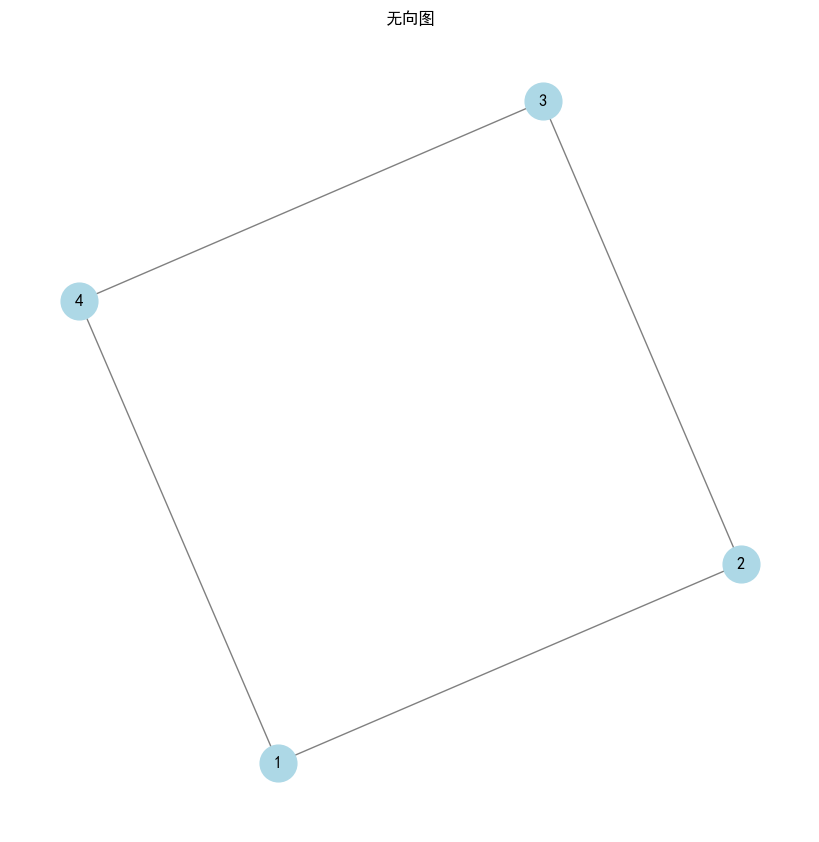

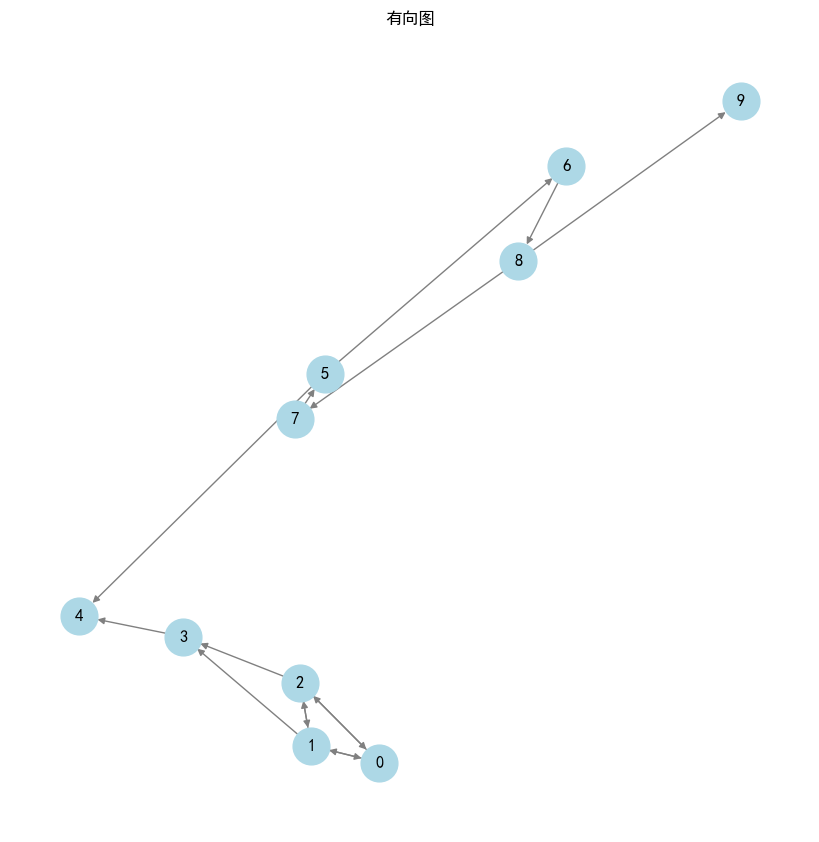

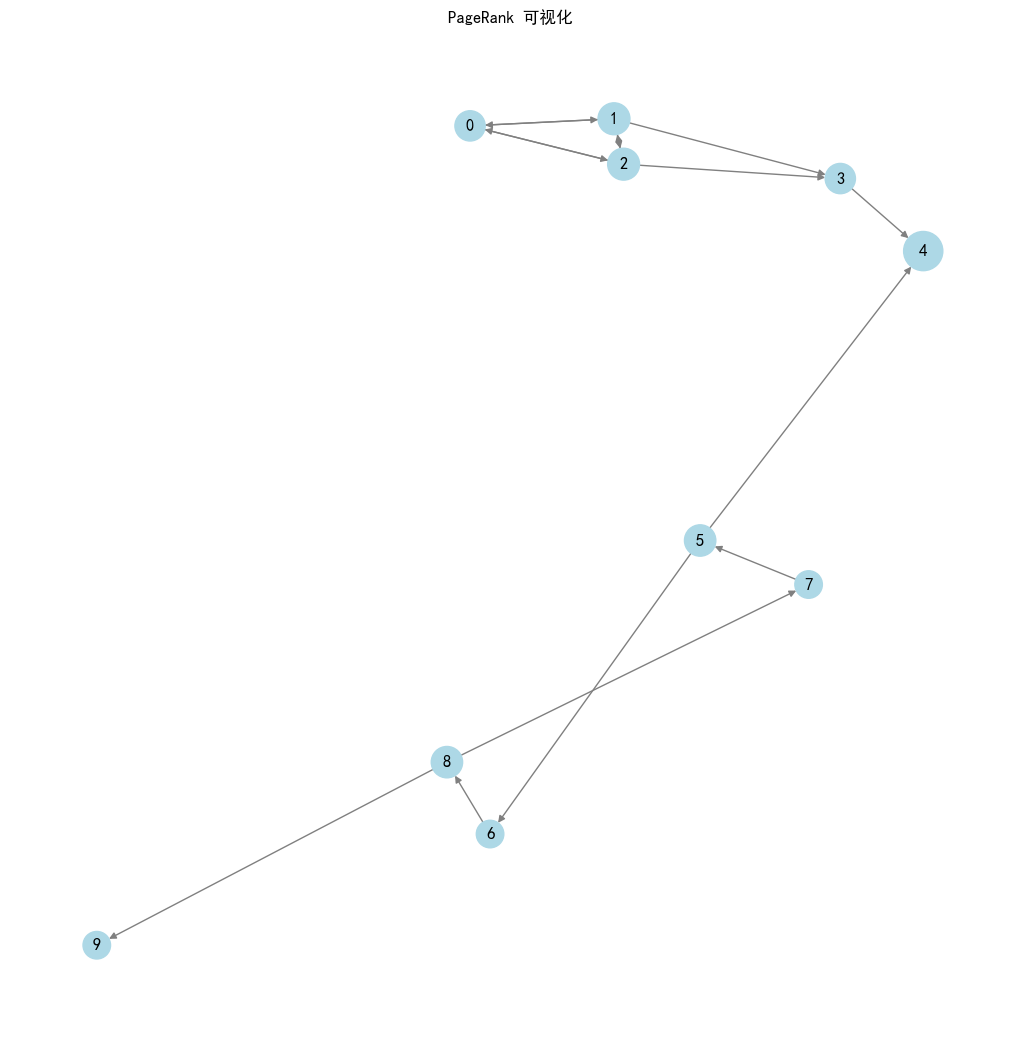

PageRank 值:
节点 4: 0.15931683334639937
节点 1: 0.10547659652084884
节点 2: 0.10547659652084884
节点 5: 0.1020112395832942
节点 8: 0.1020112395832942
节点 0: 0.09499069584253748
节点 3: 0.09499069584253748
节点 6: 0.0785753675867465
节点 7: 0.0785753675867465
节点 9: 0.0785753675867465


In [11]:
#6 7 8
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

def analyze_openrank(file_path, country="美国", top_n=100):
    data = pd.read_csv(file_path, encoding='utf-8')
    usa_data = data[data['国家'] == country].nlargest(top_n, '排名')
    value_stats = {
        "最大值": usa_data['数值'].max(),
        "最小值": usa_data['数值'].min(),
        "平均值": usa_data['数值'].mean(),
        "中位数": usa_data['数值'].median()
    }
    print("OpenRank 分析结果:")
    print(value_stats)
    return value_stats

def analyze_growth_rate(file_path, country="美国", top_n=10):
    data = pd.read_csv(file_path, encoding='utf-8')
    usa_data = data[data['国家'] == country].nlargest(top_n, '排名')
    avg_growth_rate = usa_data['增长率'].mean()
    print(f"2022年排名前十项目在美国的平均增长率: {avg_growth_rate}")
    return avg_growth_rate

def compare_open_source(file_china, file_global):
    china_data = pd.read_csv(file_china, encoding='utf-8').head(10)
    global_data = pd.read_csv(file_global, encoding='utf-8').head(10)
    china_stats = china_data.describe()
    global_stats = global_data.describe()
    print("中国前十企业的统计信息:")
    print(china_stats)
    print("全球前十企业的统计信息:")
    print(global_stats)
    return china_stats, global_stats

def draw_undirected_graph(users, edges):
    G = nx.Graph()
    G.add_nodes_from(users)
    G.add_edges_from(edges)
    plt.figure(figsize=(8, 8))
    nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray', node_size=700, font_family='SimHei')
    plt.title("无向图")
    plt.show()

def draw_directed_graph(users, edges):
    G = nx.DiGraph()
    G.add_nodes_from(users)
    G.add_edges_from(edges)
    plt.figure(figsize=(8, 8))
    nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray', node_size=700, font_family='SimHei')
    plt.title("有向图")
    plt.show()
    return G

def visualize_pagerank(G):
    pr = nx.pagerank(G)
    pr_sorted = sorted(pr.items(), key=lambda x: x[1], reverse=True)
    node_sizes = [v * 5000 for v in pr.values()]

    plt.figure(figsize=(10, 10))
    nx.draw(
        G, 
        with_labels=True, 
        node_color='lightblue', 
        edge_color='gray', 
        node_size=node_sizes,
        font_family='SimHei'
    )
    plt.title("PageRank 可视化")
    plt.show()

    print("PageRank 值:")
    for node, rank in pr_sorted:
        print(f"节点 {node}: {rank}")
    return pr_sorted

path_openrank = "/mnt/data/2023_6/openrank.csv"
path_activity = "/mnt/data/2022/activity_2020.csv"
path_china = "/mnt/data/2022/china_2022.csv"
path_global = "/mnt/data/2022/global_2022.csv"

users_undirected = [1, 2, 3, 4]
edges_undirected = [(1, 2), (2, 3), (3, 4), (4, 1)]
draw_undirected_graph(users_undirected, edges_undirected)

users_directed = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
edges_directed = [
    (0, 1), (1, 0), (0, 2), (2, 0), (1, 2), (2, 1), 
    (1, 3), (2, 3), (3, 4), (5, 4), (5, 6), (7, 5), 
    (6, 8), (8, 7), (8, 9)
]
G_directed = draw_directed_graph(users_directed, edges_directed)

pagerank_result = visualize_pagerank(G_directed)